Training data shape: (120, 4)
Testing data shape: (30, 4)

Testing MLP with hidden_layers=[8], activation=relu
Test Accuracy: 0.8333
Test Loss: 0.3072

Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.8333
Test Loss: 0.3033

Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.8000
Test Loss: 0.5115

Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 0.9667
Test Loss: 0.1158

Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 0.9333
Test Loss: 0.1370

Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.8333
Test Loss: 0.4888

Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 0.9333
Test Loss: 0.0933

Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 0.9667
Test Loss: 0.0829

Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9667
Test Loss: 0.4344

MLP CONFIGURATION RESULTS
---------------------------------

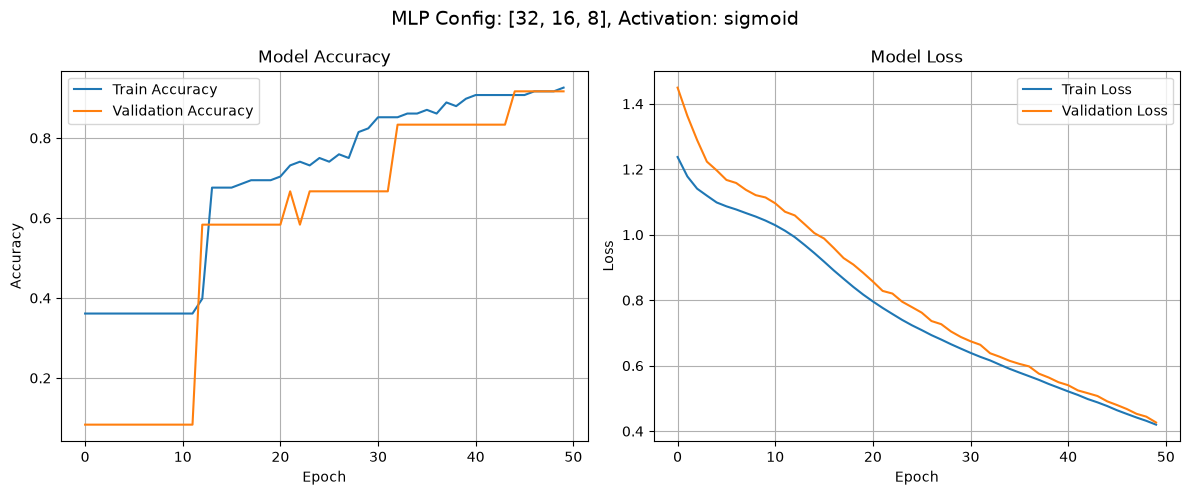

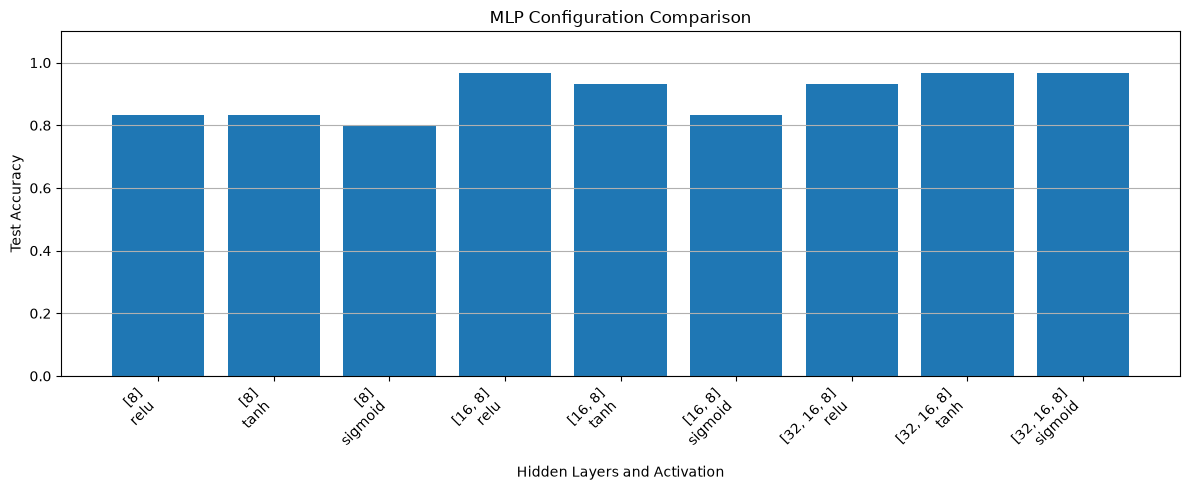


Enter Iris Flower Measurements


Sepal length (cm):  10
Sepal width (cm):  5
Petal length (cm):  5
Petal width (cm):  6



Predicted Iris Species: virginica
Prediction Probabilities: [0.00992348 0.20343381 0.7866427 ]

Sample Predictions
Actual: setosa          Predicted: setosa
Actual: virginica       Predicted: virginica
Actual: versicolor      Predicted: versicolor
Actual: versicolor      Predicted: versicolor
Actual: setosa          Predicted: setosa
Actual: versicolor      Predicted: versicolor
Actual: setosa          Predicted: setosa
Actual: setosa          Predicted: setosa
Actual: virginica       Predicted: virginica
Actual: versicolor      Predicted: versicolor

Experiment 2 Completed Successfully!


In [1]:

# EX 2: MULTI-LAYER PERCEPTRON (MLP) FOR CLASSIFICATION
# Dataset: Iris

# Step 1: Import Necessary Libraries
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Step 2: Load and Preprocess Data
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)
classes = iris.target_names

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=iris.target
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Step 3: Define MLP Model Creation Function
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(output_dim, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Step 4: Train and Evaluate MLP with Various Configurations
hidden_layer_configs = [[8], [16, 8], [32, 16, 8]]
activations = ['relu', 'tanh', 'sigmoid']

results = []
histories = {}
models = {}

for hidden_layers in hidden_layer_configs:
    for activation in activations:
        print(f"\nTesting MLP with hidden_layers={hidden_layers}, activation={activation}")

        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

        results.append({
            'hidden_layers': str(hidden_layers),
            'activation': activation,
            'accuracy': test_acc,
            'loss': test_loss
        })

        histories[(str(hidden_layers), activation)] = history
        models[(str(hidden_layers), activation)] = model

# Step 5: Display Results
print("\nMLP CONFIGURATION RESULTS")
print("-" * 65)
print(f"{'Hidden Layers':<20} {'Activation':<12} {'Accuracy':<12} {'Loss':<12}")
print("-" * 65)

for result in results:
    print(
        f"{result['hidden_layers']:<20} "
        f"{result['activation']:<12} "
        f"{result['accuracy']:<12.4f} "
        f"{result['loss']:<12.4f}"
    )

# Step 6: Plot Accuracy and Loss Curves
# Plot the training history of the last configuration
last_key = (str(hidden_layer_configs[-1]), activations[-1])
history = histories[last_key]

plt.figure(figsize=(12, 5))
plt.suptitle(
    f"MLP Config: {last_key[0]}, Activation: {last_key[1]}",
    fontsize=14
)

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 7: Plot Test Accuracy for All Configurations
labels = [
    f"{r['hidden_layers']}\n{r['activation']}"
    for r in results
]
accuracies = [r['accuracy'] for r in results]

plt.figure(figsize=(12, 5))
plt.bar(labels, accuracies)
plt.xlabel('Hidden Layers and Activation')
plt.ylabel('Test Accuracy')
plt.title('MLP Configuration Comparison')
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Step 8: Predict on New Input
print("\nEnter Iris Flower Measurements")

sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

user_input = np.array([[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]])

user_input_scaled = scaler.transform(user_input)

# Use the final trained model
final_model = models[last_key]

prediction = final_model.predict(user_input_scaled, verbose=0)
predicted_class_index = np.argmax(prediction)
predicted_class_name = classes[predicted_class_index]

print("\nPredicted Iris Species:", predicted_class_name)
print("Prediction Probabilities:", prediction[0])

# Step 9: Predict Test Samples
test_predictions = final_model.predict(X_test, verbose=0)
predicted_labels = np.argmax(test_predictions, axis=1)
actual_labels = np.argmax(y_test, axis=1)

print("\nSample Predictions")
for i in range(10):
    print(
        f"Actual: {classes[actual_labels[i]]:<15} "
        f"Predicted: {classes[predicted_labels[i]]}"
    )

print("\nExperiment 2 Completed Successfully!")